# Model state

This notebook plots the model state. Specifically:

- SST
- barotropic streamfunction
- zonal average temperature
- zonal average temperature gradient
- overturning circulation
- zonal mean velocity

If not otherwise specified I will plot the average of the monthly data.
The experiments were run for one year.

In [1]:
tub_output_dir = "/g/data/e14/jb2381/anu-tub/outputs"
if pwd() != tub_output_dir 
    cd(tub_output_dir)
end
include("plotting.jl")

  Activating project at `/g/data/e14/jb2381/anu-tub/outputs`
[ Info: Plotting and analysis environment setup!
┌ Info: Experiments in the catalogue are:
│        - zstar-PPMH3
│        - hycom-PPMH3
│        Available data is:
│           - daily
│           - monthly
│           - monthlyz
│           - monthlyrho2
│           - static
└           - vertical coordinate


Set colourbar limits for all vairbales so they are the same across plots.

In [2]:
θcrange = (-2, 30)
dθcrange = (-0.2, 0.2)
ψbcrange = range(-30, 70, 30)
ucrange = (-0.05, 0.05)
ψocrange = range(-8, 8, 20)

-8.0:0.8421052631578947:8.0

## zstar

The information is either going to have to be presented on a single figure or one for each model.
I am aiming to get something that looks good here and then think about how to present the comparison.

In [3]:
zs_monthly = catalogue["zstar-PPMH3"]["monthly"]
zs_monthlyrho2 = catalogue["zstar-PPMH3"]["monthlyrho2"]
zs_monthlyz = catalogue["zstar-PPMH3"]["monthlyz"]
zs_static = catalogue["zstar-PPMH3"]["static"]
zs_vc = catalogue["zstar-PPMH3"]["vc"]

zs_crs = get_geo_coords(zs_static, zs_vc)

ds = NCDataset(zs_monthly, maskingvalue = NaN)

zs_sst = mean(ds["thetao"][:, :, 1, :], dims = 4)[:, :, 1, 1]
zs_tzm = mean(nanmean(ds["thetao"][:, :, :, :], dims = 1), dims = 4)[1, :, :, 1]
zs_uzm = nanmean(ds["uo"][:, :, :, :], dims = (1, 4))
zs_uzm = dropdims(zs_uzm, dims = (1, 4))
zs_interface_height = interface_height(zs_monthly; timestamp = 12)

close(ds)

zs_ψb = barotropic_streamfunction(zs_monthly)

zs_layer, zs_ψo = overturning_circulation(zs_monthlyz, "z_l")

zs_dθ = dθ_dz(zs_monthly)
zs_dθ = dropdims(zs_dθ, dims = (1, 4))

nothing

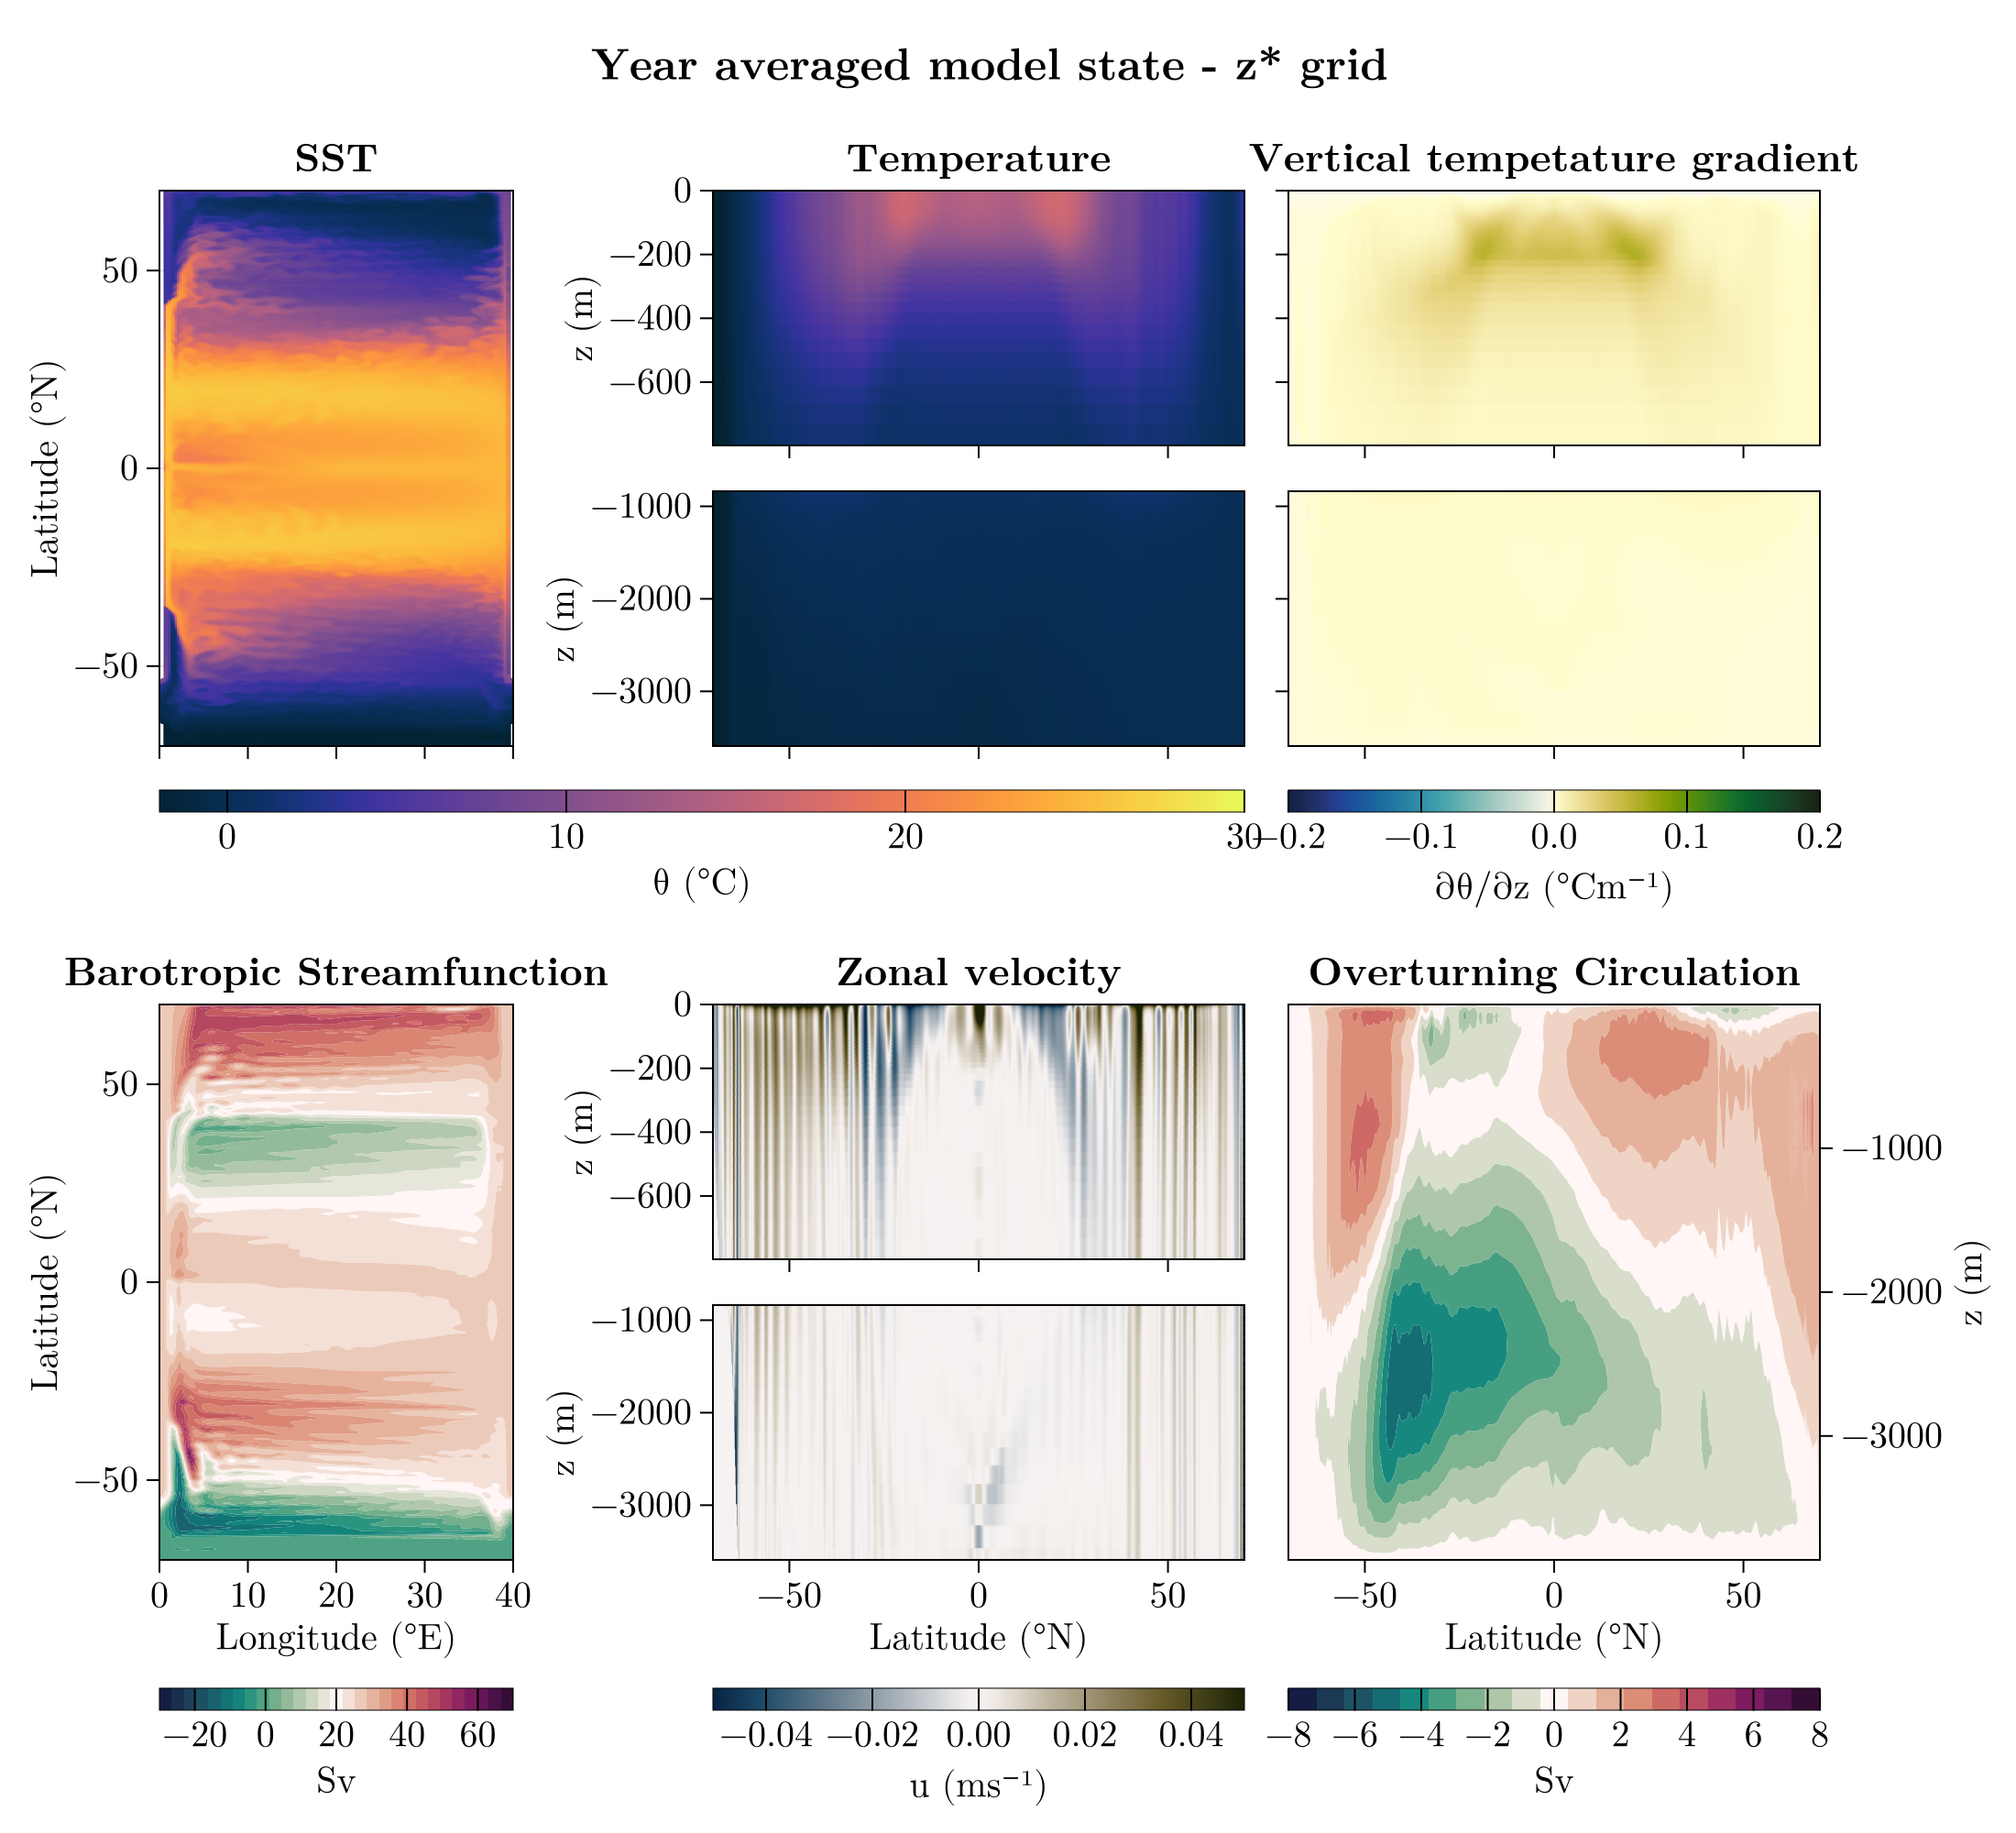

In [4]:
fig = Figure(size = (1100, 1000))

ax_sst = Axis(fig[1:2, 1], xlabel = "Longitude (°E)", ylabel = "Latitude (°N)", title = "SST")
hidexdecorations!(ax_sst, ticks = false)
hm = heatmap!(ax_sst, zs_crs.lonh, zs_crs.lath, zs_sst, colorrange = θcrange, colormap = :thermal)

top = 1:55
bot = top[end]+1:74

axtop = Axis(fig[1, 2], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "Temperature")
hm = heatmap!(axtop, zs_crs.lath, zs_crs.zl[top], zs_tzm[:, top], colorrange = θcrange, colormap = :thermal)
axbot = Axis(fig[2, 2], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot, zs_crs.lath, zs_crs.zl[bot], zs_tzm[:, bot], colorrange = θcrange, colormap = :thermal)
ylims!(axbot, zs_crs.zl[bot[end]], zs_crs.zl[bot[1]])
Colorbar(fig[3, 1:2], hm, vertical = false, flipaxis = false, label = "θ (°C)")

hidexdecorations!(axtop, ticks = false)
hidexdecorations!(axbot, ticks = false)

axtop = Axis(fig[1, 3], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "Vertical tempetature gradient")
hm = heatmap!(axtop, zs_crs.lath, zs_crs.zl[top], zs_dθ[:, top]; colorrange = dθcrange, colormap = :delta)
axbot = Axis(fig[2, 3], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot, zs_crs.lath, zs_crs.zl[bot], zs_dθ[:, bot]; colorrange = dθcrange, colormap = :delta)
ylims!(axbot, zs_crs.zl[bot[end]], zs_crs.zl[bot[1]])
Colorbar(fig[3, 3], hm, vertical = false, flipaxis = false, label = "∂θ/∂z (°Cm⁻¹)")

hidexdecorations!(axtop, ticks = false)
hidexdecorations!(axbot, ticks = false)
hideydecorations!(axtop, ticks = false)
hideydecorations!(axbot, ticks = false)

ax_ψb = Axis(fig[4:5, 1], xlabel = "Longitude (°E)", ylabel = "Latitude (°N)", title = "Barotropic Streamfunction")
xlims!(ax_ψb, zs_crs.lonq[1], zs_crs.lonq[end])
ylims!(ax_ψb, zs_crs.lath[1], zs_crs.lath[end])
cf = contourf!(ax_ψb, zs_crs.lonq, zs_crs.lath, zs_ψb[:, :, 1], colormap = :curl, levels = ψbcrange)
Colorbar(fig[6, 1], cf, vertical = false, flipaxis = false, label = "Sv")

# linkxaxes!(ax_sst, ax_ψb)

axtop = Axis(fig[4, 2], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "Zonal velocity")
hm = heatmap!(axtop, zs_crs.lath, zs_crs.zl[top], zs_uzm[:, top]; colorrange = ucrange, colormap = :diff)
axbot = Axis(fig[5, 2], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot, zs_crs.lath, zs_crs.zl[bot], zs_uzm[:, bot]; colorrange = ucrange, colormap = :diff)
ylims!(axbot, zs_crs.zl[bot[end]], zs_crs.zl[bot[1]])
Colorbar(fig[6, 2], hm, vertical = false, flipaxis = false, label = "u (ms⁻¹)")

hidexdecorations!(axtop, ticks = false)

# density-latitude
# ax_ψo = Axis(fig[4:5, 3], xlabel = "Latitude (°N)", ylabel = "Potential density (kgm⁻³)", title = "Overturning Circulation",
#              yaxisposition = :right)
# cf = contourf!(ax_ψo, zs_crs.latq, zs_layer, zs_ψo[1, :, :, 1], colormap = :balance, levels = ψocrange)
# Colorbar(fig[6, 3], cf, vertical = false, flipaxis = false, label = "Sv")
# xlims!(ax_ψo, zs_crs.latq[1], zs_crs.latq[end])
# ylims!(ax_ψo, zs_ρolayer[end], 1034)
# ax_ψo.yreversed = true

# # depth-latitude
ax_ψo = Axis(fig[4:5, 3], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "Overturning Circulation",
             yaxisposition = :right)
cf = contourf!(ax_ψo, zs_crs.latq, zs_crs.zl, zs_ψo[1, :, :, 1], colormap = :curl, levels = ψocrange)
Colorbar(fig[6, 3], cf, vertical = false, flipaxis = false, label = "Sv")
xlims!(ax_ψo, zs_crs.latq[1], zs_crs.latq[end])
ylims!(ax_ψo, zs_crs.zl[end], zs_crs.zl[1])

colsize!(fig.layout, 1, Relative(1/4))

Label(fig[0, :], "Year averaged model state - z* grid", fontsize = 24, font = :bold)

fig

In [5]:
save("modelstate_zstar.png", fig)

## HYCOM

In [5]:
hy_key = "hycom-PPMH3"

hy_monthly = catalogue[hy_key]["monthly"]
hy_monthlyrho2 = catalogue[hy_key]["monthlyrho2"]
hy_monthlyz = catalogue[hy_key]["monthlyz"]
hy_static = catalogue[hy_key]["static"]
hy_vc = catalogue[hy_key]["vc"]

hy_crs = get_geo_coords(hy_static, hy_vc)

ds = NCDataset(hy_monthly, maskingvalue = NaN)

hy_sst = mean(ds["thetao"][:, :, 1, :], dims = 4)[:, :, 1, 1]
hy_tzm = mean(nanmean(ds["thetao"][:, :, :, :], dims = 1), dims = 4)[1, :, :, 1]
hy_uzm = nanmean(ds["uo"][:, :, :, :], dims = (1, 4))
hy_uzm = dropdims(hy_uzm, dims = (1, 4))

close(ds)

hy_ψb = barotropic_streamfunction(hy_monthly)

hy_ρolayer, hy_ψo = overturning_circulation(hy_monthlyz, "z_l")

hy_dθ = dθ_dz(hy_monthly)
hy_dθ = dropdims(hy_dθ, dims = (1, 4))
nothing

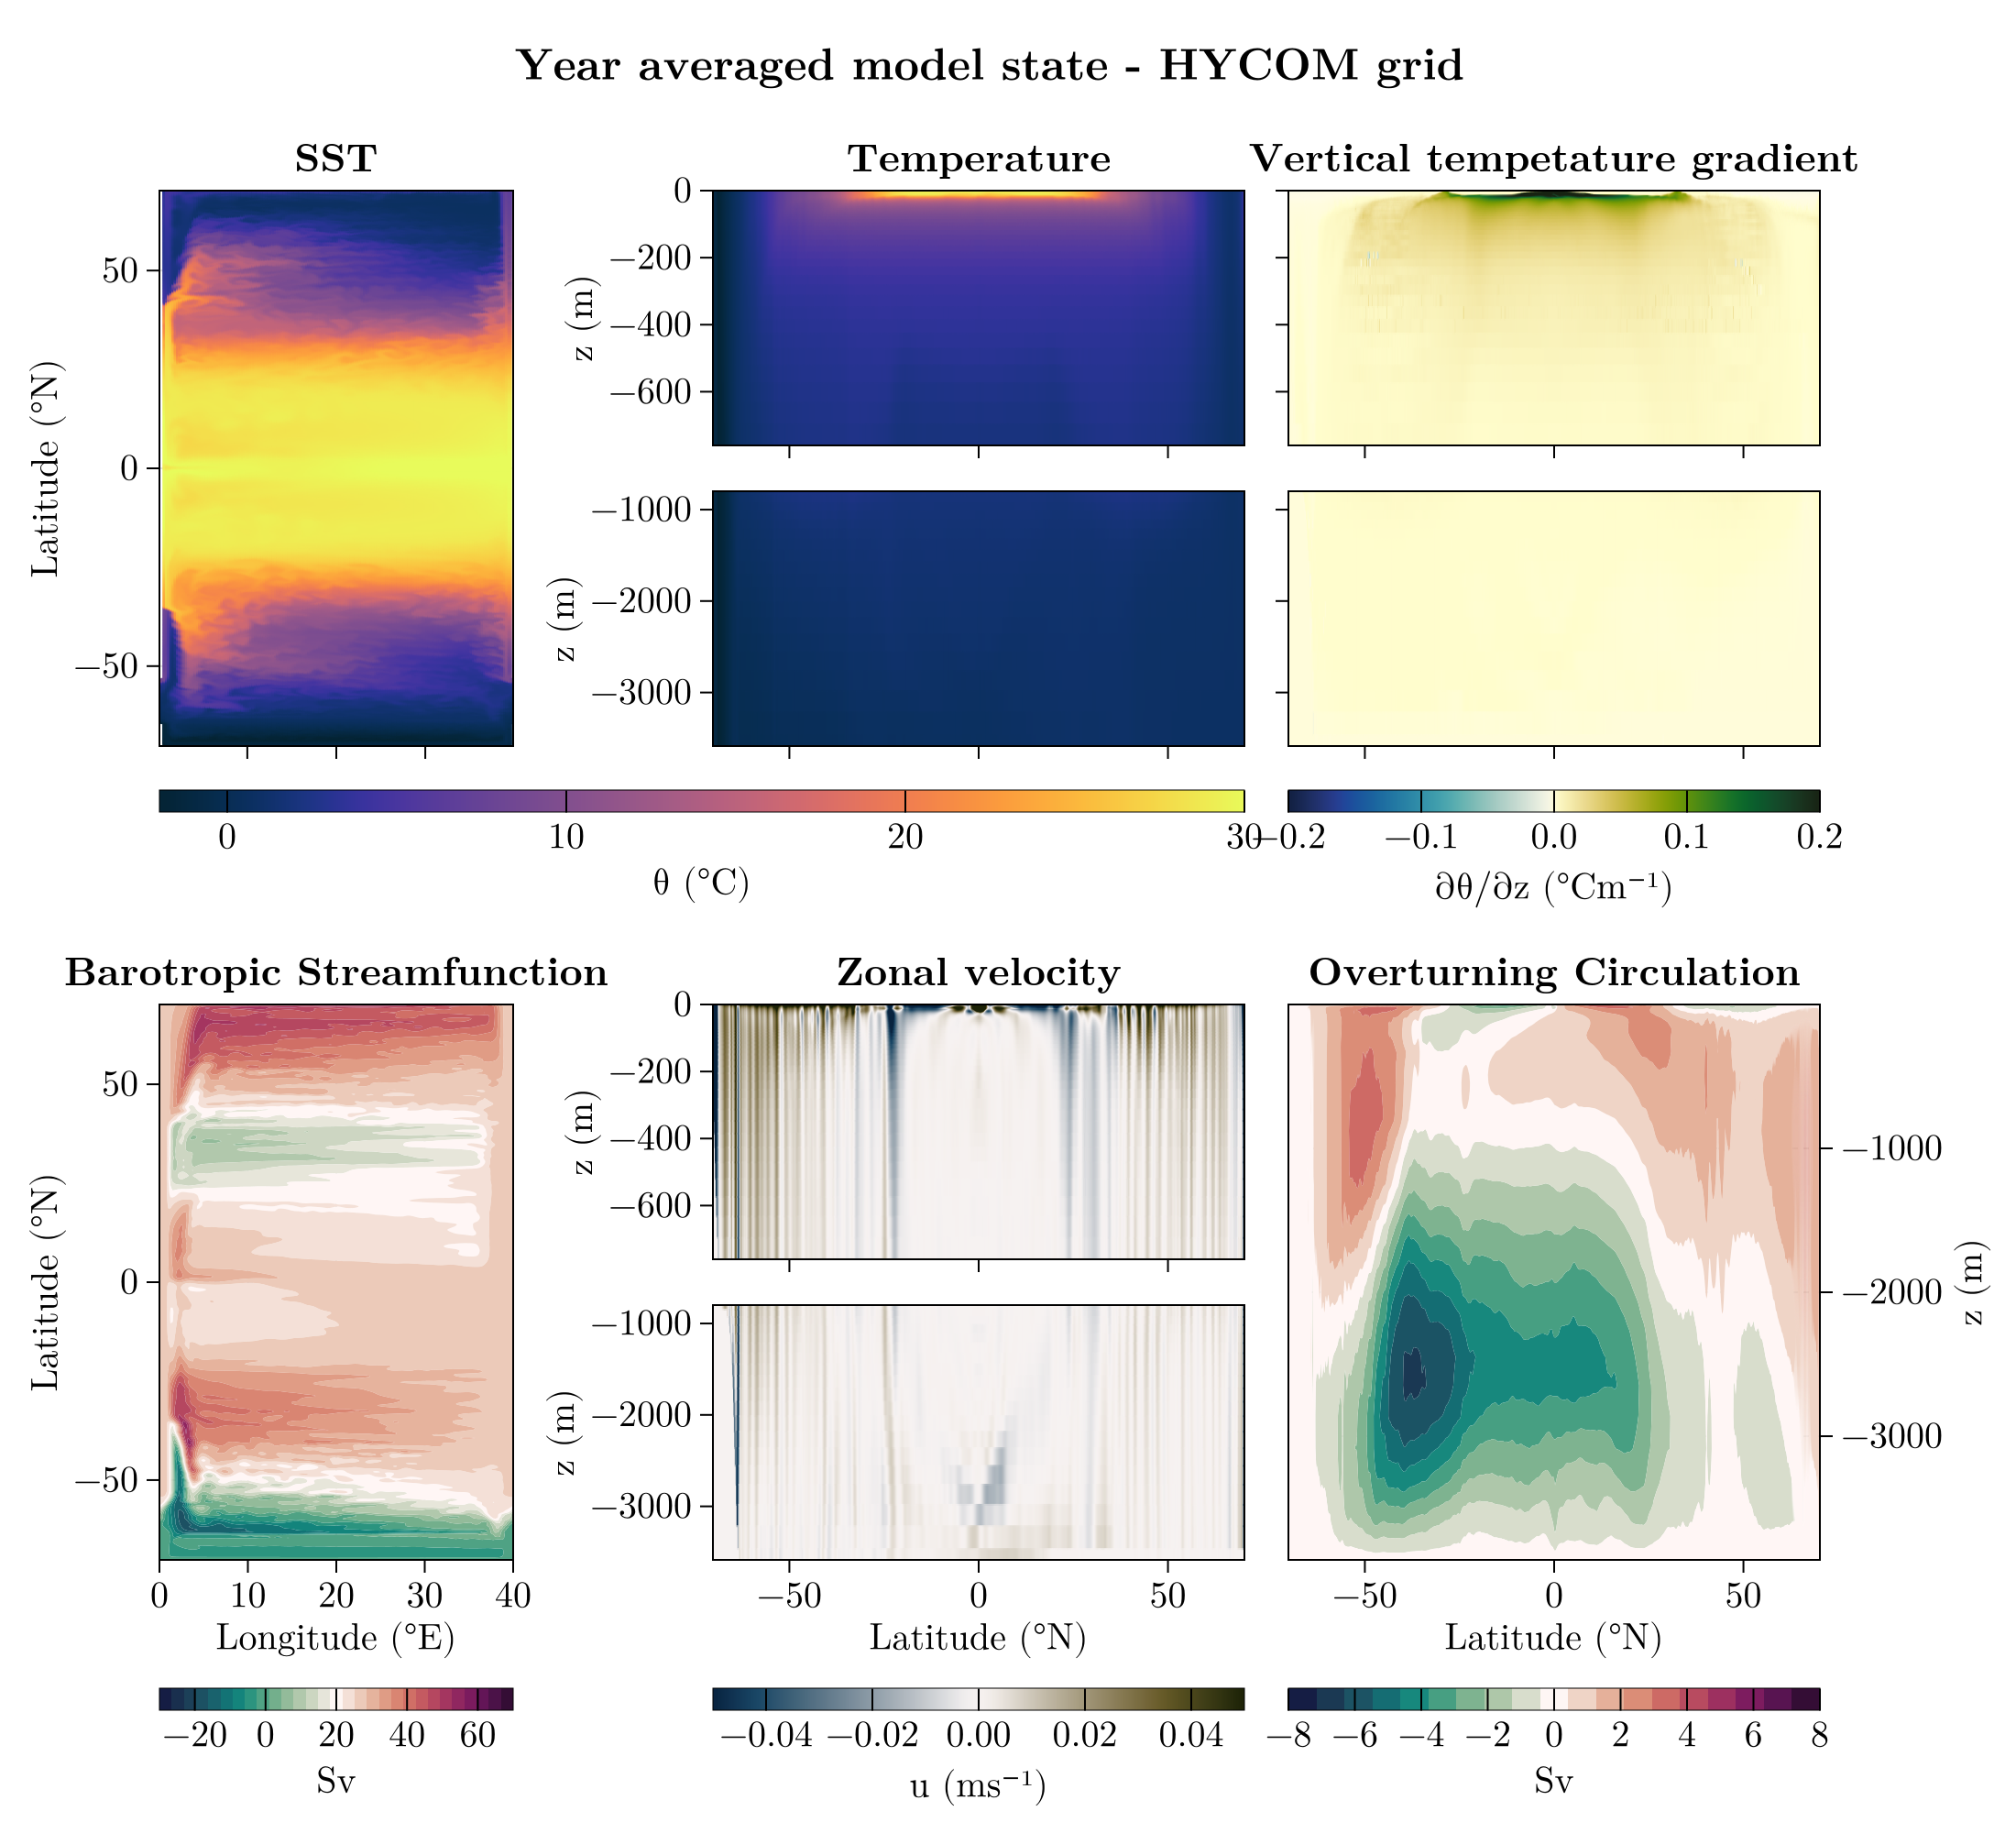

In [6]:
fig = Figure(size = (1100, 1000))

ax_sst = Axis(fig[1:2, 1], xlabel = "Longitude (°E)", ylabel = "Latitude (°N)", title = "SST")
xlims!(ax_sst, hy_crs.lonh[1], hy_crs.lonh[end])
hidexdecorations!(ax_sst, ticks = false)
hm = heatmap!(ax_sst, hy_crs.lonh, hy_crs.lath, hy_sst, colorrange = θcrange, colormap = :thermal)

top = 1:55
bot = top[end]+1:74

axtop = Axis(fig[1, 2], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "Temperature")
hm = heatmap!(axtop, hy_crs.lath, hy_crs.zl[top], hy_tzm[:, top], colorrange = θcrange, colormap = :thermal)
axbot = Axis(fig[2, 2], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot, hy_crs.lath, hy_crs.zl[bot], hy_tzm[:, bot], colorrange = θcrange, colormap = :thermal)
ylims!(axbot, hy_crs.zl[bot[end]], hy_crs.zl[bot[1]])
Colorbar(fig[3, 1:2], hm, vertical = false, flipaxis = false, label = "θ (°C)")

hidexdecorations!(axtop, ticks = false)
hidexdecorations!(axbot, ticks = false)

axtop = Axis(fig[1, 3], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "Vertical tempetature gradient")
hm = heatmap!(axtop, hy_crs.lath, hy_crs.zl[top], hy_dθ[:, top]; colorrange = dθcrange, colormap = :delta)
axbot = Axis(fig[2, 3], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot, hy_crs.lath, hy_crs.zl[bot], hy_dθ[:, bot]; colorrange = dθcrange, colormap = :delta)
ylims!(axbot, hy_crs.zl[bot[end]], hy_crs.zl[bot[1]])
Colorbar(fig[3, 3], hm, vertical = false, flipaxis = false, label = "∂θ/∂z (°Cm⁻¹)")

hidexdecorations!(axtop, ticks = false)
hidexdecorations!(axbot, ticks = false)
hideydecorations!(axtop, ticks = false)
hideydecorations!(axbot, ticks = false)

ax_ψb = Axis(fig[4:5, 1], xlabel = "Longitude (°E)", ylabel = "Latitude (°N)", title = "Barotropic Streamfunction")
xlims!(ax_ψb, hy_crs.lonq[1], hy_crs.lonq[end])
ylims!(ax_ψb, hy_crs.lath[1], hy_crs.lath[end])
cf = contourf!(ax_ψb, hy_crs.lonq, hy_crs.lath, hy_ψb[:, :, 1], colormap = :curl, levels = ψbcrange)
Colorbar(fig[6, 1], cf, vertical = false, flipaxis = false, label = "Sv")

# linkxaxes!(ax_sst, ax_ψb)

axtop = Axis(fig[4, 2], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "Zonal velocity")
hm = heatmap!(axtop, hy_crs.lath, hy_crs.zl[top], hy_uzm[:, top]; colorrange = ucrange, colormap = :diff)
axbot = Axis(fig[5, 2], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot, hy_crs.lath, hy_crs.zl[bot], hy_uzm[:, bot]; colorrange = ucrange, colormap = :diff)
ylims!(axbot, hy_crs.zl[bot[end]], hy_crs.zl[bot[1]])
Colorbar(fig[6, 2], hm, vertical = false, flipaxis = false, label = "u (ms⁻¹)")

hidexdecorations!(axtop, ticks = false)

# # density-latitude
# ax_ψo = Axis(fig[4:5, 3], xlabel = "Latitude (°N)", ylabel = "Potential density (kgm⁻³)", title = "Overturning Circulation",
#              yaxisposition = :right)
# cf = contourf!(ax_ψo, hy_crs.latq, hy_ρolayer, hy_ψo[1, :, :, 1], colormap = :balance, levels = 20)
# Colorbar(fig[6, 3], cf, vertical = false, flipaxis = false, label = "Sv")
# ax_ψo.yreversed = true
# ylims!(ax_ψo, hy_ρolayer[end], 1034)

#  depth-latitude
ax_ψo = Axis(fig[4:5, 3], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "Overturning Circulation",
             yaxisposition = :right)
cf = contourf!(ax_ψo, hy_crs.latq, hy_crs.zl, hy_ψo[1, :, :, 1], colormap = :curl, levels = ψocrange)
Colorbar(fig[6, 3], cf, vertical = false, flipaxis = false, label = "Sv")
xlims!(ax_ψo, hy_crs.latq[1], hy_crs.latq[end])
ylims!(ax_ψo, hy_crs.zl[end], hy_crs.zl[1])

colsize!(fig.layout, 1, Relative(1/4))

Label(fig[0, :], "Year averaged model state - HYCOM grid", fontsize = 24, font = :bold)

fig

In [12]:
save("modelstate_hycom.png", fig)

# Difference between zstar and zstar-isopycnal

For these to make sense need to compare on same grid (probably z) but then they will have been remapped.

In [66]:
# error
ae_sst = zs_sst .- hy_sst
ae_tzm = zs_tzm .- hy_tzm
ae_dθ = zs_dθ .- hy_dθ
ae_ψb = zs_ψb[:, :, 1] .- hy_ψb[:, :, 1]
ae_uzm = zs_uzm .- hy_uzm
ae_ψo = zs_ψo[1, :, :, 1] .- hy_ψo[1, :, :, 1]


dθmax = nanmaximum(abs.(ae_sst))
dθcrange = (-dθmax, dθmax)
ddθmax = nanmaximum(abs.(ae_dθ))
ddθcrange = (-ddθmax, ddθmax)
dψb = nanmaximum(abs.(ae_ψb))
dψbcrange = (-dψb, dψb)
dumax = nanmaximum(abs.(ae_uzm))
ducrange = (-dumax, dumax)
dψo = nanmaximum(abs.(ae_ψo))
dψocrange = (-dψo, dψo)

# abs error
# ae_sst = abs.(zs_sst .- hy_sst)                      
# ae_tzm = abs.(zs_tzm .- hy_tzm)                      
# ae_dθ = abs.(zs_dθ .- hy_dθ)                         
# ae_ψb = abs.(zs_ψb[:, :, 1] .- hy_ψb[:, :, 1])       
# ae_uzm = abs.(zs_uzm .- hy_uzm)                      
# ae_ψo = abs.(zs_ψo[1, :, :, 1] .- hy_ψo[1, :, :, 1]) 

# dθcrange = (0, nanmaximum(ae_sst))
# ddθcrange = (0, nanmaximum(ae_dθ))
# dψbcrange = (0, nanmaximum(ae_ψb))
# ducrange = (0, nanmaximum(ae_uzm))
# dψocrange = (0, nanmaximum(ae_ψo))

(-1.1210304648624534, 1.1210304648624534)

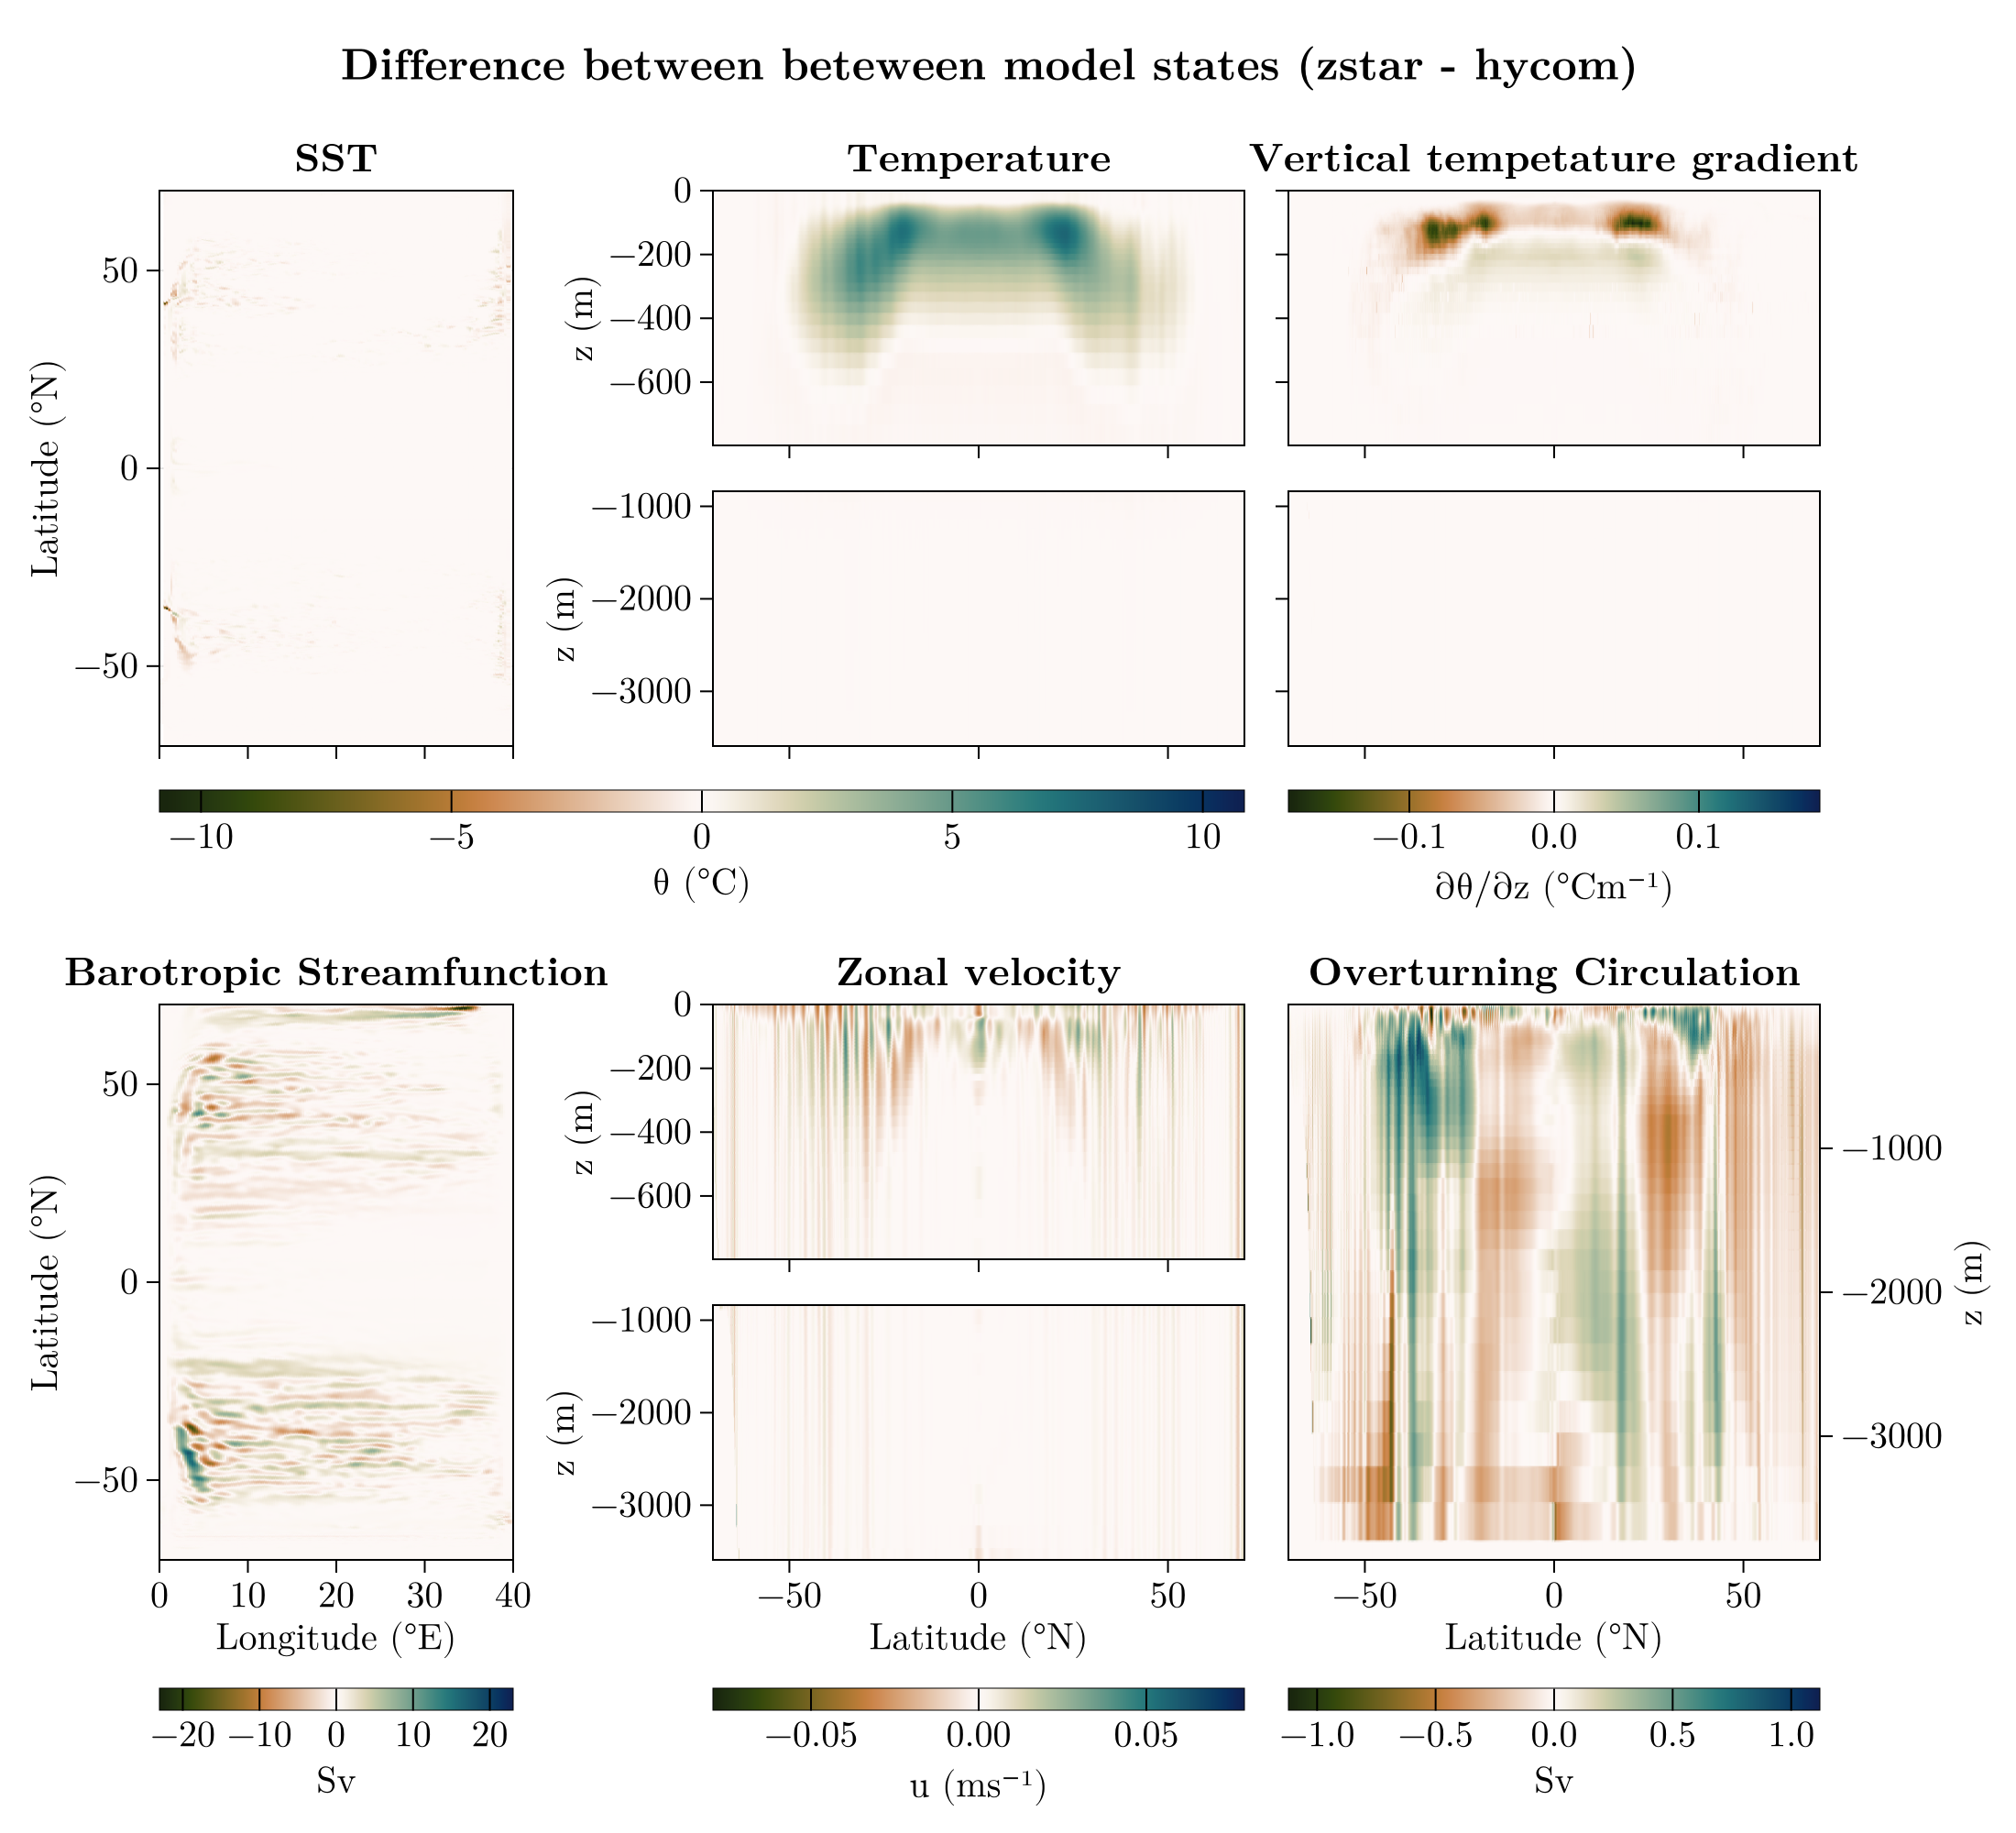

In [70]:
fig = Figure(size = (1100, 1000))

# colormap = :amp # for abosolute error
colormap = :tarn # for difference

ax_sst = Axis(fig[1:2, 1], xlabel = "Longitude (°E)", ylabel = "Latitude (°N)", title = "SST")
hidexdecorations!(ax_sst, ticks = false)
hm = heatmap!(ax_sst, zs_crs.lonh, zs_crs.lath, ae_sst; colormap, colorrange = dθcrange)

top = 1:55
bot = top[end]+1:74

axtop = Axis(fig[1, 2], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "Temperature")
hm = heatmap!(axtop, zs_crs.lath, zs_crs.zl[top], ae_tzm[:, top]; colormap, colorrange = dθcrange)
axbot = Axis(fig[2, 2], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot, zs_crs.lath, zs_crs.zl[bot], ae_tzm[:, bot]; colormap, colorrange = dθcrange)
ylims!(axbot, zs_crs.zl[bot[end]], zs_crs.zl[bot[1]])
Colorbar(fig[3, 1:2], hm, vertical = false, flipaxis = false, label = "θ (°C)")

hidexdecorations!(axtop, ticks = false)
hidexdecorations!(axbot, ticks = false)

axtop = Axis(fig[1, 3], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "Vertical tempetature gradient")
hm = heatmap!(axtop, zs_crs.lath, zs_crs.zl[top], ae_dθ[:, top]; colormap, colorrange = ddθcrange)
axbot = Axis(fig[2, 3], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot, zs_crs.lath, zs_crs.zl[bot], ae_dθ[:, bot]; colormap, colorrange = ddθcrange)
ylims!(axbot, zs_crs.zl[bot[end]], zs_crs.zl[bot[1]])
Colorbar(fig[3, 3], hm, vertical = false, flipaxis = false, label = "∂θ/∂z (°Cm⁻¹)")

hidexdecorations!(axtop, ticks = false)
hidexdecorations!(axbot, ticks = false)
hideydecorations!(axtop, ticks = false)
hideydecorations!(axbot, ticks = false)

ax_ψb = Axis(fig[4:5, 1], xlabel = "Longitude (°E)", ylabel = "Latitude (°N)", title = "Barotropic Streamfunction")
xlims!(ax_ψb, zs_crs.lonq[1], zs_crs.lonq[end])
ylims!(ax_ψb, zs_crs.lath[1], zs_crs.lath[end])
cf = heatmap!(ax_ψb, zs_crs.lonq, zs_crs.lath, ae_ψb; colormap, colorrange = dψbcrange)
Colorbar(fig[6, 1], cf, vertical = false, flipaxis = false, label = "Sv")

# linkxaxes!(ax_sst, ax_ψb)

axtop = Axis(fig[4, 2], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "Zonal velocity")
hm = heatmap!(axtop, zs_crs.lath, zs_crs.zl[top], ae_uzm[:, top]; colormap, colorrange = ducrange)
axbot = Axis(fig[5, 2], xlabel = "Latitude (°N)", ylabel = "z (m)")
hm = heatmap!(axbot, zs_crs.lath, zs_crs.zl[bot], ae_uzm[:, bot]; colormap, colorrange = ducrange)
ylims!(axbot, zs_crs.zl[bot[end]], zs_crs.zl[bot[1]])
Colorbar(fig[6, 2], hm, vertical = false, flipaxis = false, label = "u (ms⁻¹)")

hidexdecorations!(axtop, ticks = false)

# # density-latitude
# ax_ψo = Axis(fig[4:5, 3], xlabel = "Latitude (°N)", ylabel = "Potential density (kgm⁻³)", title = "Overturning Circulation",
#              yaxisposition = :right)
# cf = heatmap!(ax_ψo, zs_crs.latq, zs_ρolayer, zs_ψo[1, :, :, 1] .- hy_ψo[1, :, :, 1]; colormap, colorrange = dψocrange)
# Colorbar(fig[6, 3], cf, vertical = false, flipaxis = false, label = "Sv")
# xlims!(ax_ψo, zs_crs.latq[1], zs_crs.latq[end])
# ylims!(ax_ψo, zs_ρolayer[end], 1034)
# ax_ψo.yreversed = true

#  depth-latitude
ax_ψo = Axis(fig[4:5, 3], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "Overturning Circulation",
             yaxisposition = :right)
# cf = contourf!(ax_ψo, hy_crs.latq, hy_crs.zl, ae_ψo; colormap, levels = dψocrange)
cf = heatmap!(ax_ψo, hy_crs.latq, hy_crs.zl, ae_ψo; colormap, colorrange = dψocrange)
Colorbar(fig[6, 3], cf, vertical = false, flipaxis = false, label = "Sv")
xlims!(ax_ψo, hy_crs.latq[1], hy_crs.latq[end])
ylims!(ax_ψo, hy_crs.zl[end], hy_crs.zl[1])

colsize!(fig.layout, 1, Relative(1/4))

Label(fig[0, :], "Difference between beteween model states (zstar - hycom)", fontsize = 24, font = :bold)

fig

In [71]:
save("modelstate_diff.png", fig)